# 04 — Contexto regulatório

**Objetivo:** as etapas 4 e 5 descreveram duas mudanças de patamar em
out/2025 — o percentual de devolução oscila mais e o volume de contestações
triplica, com queda acelerada na taxa de aceite. Nenhuma das duas etapas
explicou *por quê*. Dado não explica dado: esta etapa busca fora da base uma
explicação, com fonte oficial, e sobrepõe as datas à série pra ver se batem.

Faz parte da [etapa 6](../README.md#progresso) do projeto.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys
import urllib.request

sys.path.insert(0, "..")
if not os.path.exists("../visual.py"):  # fora do repositorio (ex: Colab): baixa o padrao visual
    urllib.request.urlretrieve("https://raw.githubusercontent.com/ivadivad/med-em-numeros/main/visual.py", "visual.py")
from visual import grafico, salvar, eixo_milhoes, AZUL, LARANJA

URL = "https://raw.githubusercontent.com/ivadivad/med-em-numeros/main/dados/fraude.csv"
df = pd.read_csv(URL)
df["Data"] = pd.to_datetime(df["AnoMes"], format="%Y%m")
df = df.sort_values("Data").reset_index(drop=True)
df["taxa_aceite"] = df["Qtdecontestacoesaceitas"] / df["QtdePixcontestados"] * 100
df.shape

(52, 26)

## Linha do tempo regulatória

Pesquisei mudanças de regra do MED/Pix publicadas pelo Banco Central ou por
veículos de imprensa citando o BC, com link verificável — nada aqui vem de
memória.

| Data | O que mudou | Fonte |
|---|---|---|
| **01/10/2025** | Pix ganha "botão de contestação" em todos os aplicativos bancários: o MED passa a poder ser acionado "de forma totalmente digital, sem necessidade de atendimento humano" | [InfoMoney](https://www.infomoney.com.br/brasil/pix-tera-botao-para-contestar-fraudes-a-partir-de-1o-de-outubro-diz-bc/) (data e anúncio do BC), [TechTudo](https://www.techtudo.com.br/noticias/2025/10/pix-lanca-botao-de-contestacao-hoje-1-entenda-como-funciona-edapps.ghtml) (trecho citado) |
| **23/11/2025** | MED 2.0 entra em vigor: passa a ser possível rastrear e devolver dinheiro que já foi transferido pra *outras* contas, não só a primeira que recebeu o Pix. Adoção **facultativa** pelas instituições | [Agência Brasil](https://agenciabrasil.ebc.com.br/economia/noticia/2025-11/veja-como-vai-funcionar-devolucao-do-pix-em-caso-de-golpe) |
| **02/02/2026** | MED 2.0 (rastreio em outras contas) vira **obrigatório** pra todas as instituições | [Agência Brasil](https://agenciabrasil.ebc.com.br/economia/noticia/2025-11/veja-como-vai-funcionar-devolucao-do-pix-em-caso-de-golpe) |
| 01/09/2026 | Prazo pro **recebedor** de um Pix contestar um estorno indevido sobe de 30 pra 80 dias (iguala ao prazo que a vítima já tinha) — fecha brecha do "golpe da devolução duplicada". **Fora do período coletado** (dados vão até abr/2026) | [Correio24Horas](https://www.correio24horas.com.br/economia/golpe-do-pix-banco-central-amplia-para-80-dias-prazo-para-lojistas-contestarem-estornos-indevidos-0926) |

**Uma correção no caminho:** a primeira leitura da última linha supôs que o
prazo de 80 dias era da *vítima* pra contestar o golpe — repetindo um erro
que já estava em notas antigas deste projeto. Conferindo a fonte direto, não
é isso: é o prazo do **recebedor** (quem recebeu o Pix) pra contestar um
estorno que já caiu contra ele. Prazo da vítima continua sendo outro.

In [2]:
datas_regulatorias = {
    "2025-10-01": "Botão de contestação\n(100% digital)",
    "2025-11-23": "MED 2.0\n(facultativo)",
    "2026-02-02": "MED 2.0\n(obrigatório)",
}
list(datas_regulatorias.items())

[('2025-10-01', 'Botão de contestação\n(100% digital)'),
 ('2025-11-23', 'MED 2.0\n(facultativo)'),
 ('2026-02-02', 'MED 2.0\n(obrigatório)')]

## Sobrepondo as datas aos gráficos

As três datas que caem dentro do período coletado (a de set/2026 fica de
fora), marcadas com `axvline` sobre as duas séries que mostraram quebra nas
etapas 4 e 5.

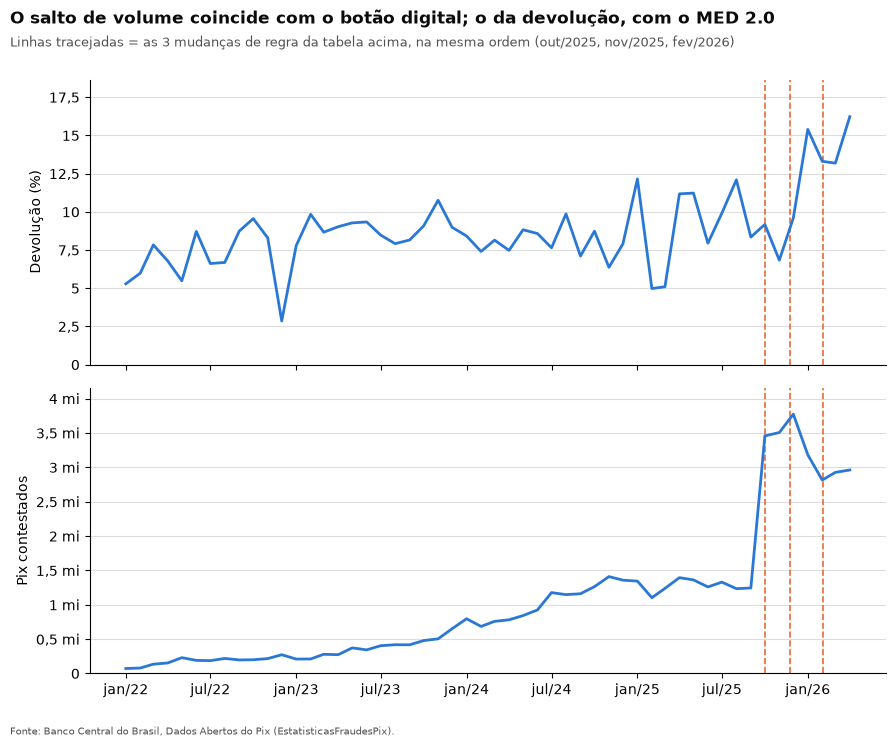

In [3]:
fig, (ax1, ax2) = grafico(
    "O salto de volume coincide com o botão digital; o da devolução, com o MED 2.0",
    subtitulo="Linhas tracejadas = as 3 mudanças de regra da tabela acima, na mesma ordem (out/2025, nov/2025, fev/2026)",
    linhas=2, figsize=(9, 7.5),
)
ax1.plot(df["Data"], df["PercentualdeDevolucao"], color=AZUL, linewidth=2)
ax1.set_ylim(0, df["PercentualdeDevolucao"].max() * 1.15)
ax1.set_ylabel("Devolução (%)")

ax2.plot(df["Data"], df["QtdePixcontestados"], color=AZUL, linewidth=2)
ax2.set_ylim(0, df["QtdePixcontestados"].max() * 1.1)
ax2.set_ylabel("Pix contestados")
eixo_milhoes(ax2)

for ax in (ax1, ax2):
    for data_str in datas_regulatorias:
        ax.axvline(pd.Timestamp(data_str), color=LARANJA, linewidth=1.2, linestyle="--", zorder=1)

salvar(fig, "04-contexto-regulatorio.png")
plt.show()

## Leitura

**A primeira linha (01/10/2025) coincide com a quebra real.** É o mesmo mês
em que a etapa 5 achou o salto de 178% no volume de contestações — e faz
sentido causal, não só temporal: dispensar atendimento humano pra abrir a
contestação reduz o atrito do processo. Mais fácil de abrir, mais gente abre.
(Nenhuma das duas fontes descreve como era o processo antes — o "reduz o
atrito" é inferência minha, não afirmação delas.) A fonte não prova a causa sozinha, mas dá uma
explicação plausível pra o *timing* exato da quebra, o que o dado sozinho
(etapa 5) não conseguia oferecer.

**As duas linhas seguintes (23/11/2025 e 02/02/2026): no volume, nenhuma
quebra; no percentual de devolução, sim — e a primeira versão deste texto
errou ao dizer que não.** A versão anterior afirmava que nenhuma das duas
séries mudava nessas datas. O painel de cima mostra o contrário: a devolução
passa de 9,6% em dez/2025 pra 15,4% em jan/2026 e fica entre 13% e 16% até
abr/2026. Os 4 meses de 2026 ficam acima do maior valor dos 48 meses
anteriores (12,2%), e não é sazonal — jan–abr dos anos anteriores ficou na
mesma faixa do resto do ano (a conta está no
[notebook 07](07-antes-e-depois.ipynb)).

O salto cai **entre** as duas datas, não em cima de nenhuma: depois do início
facultativo (23/11, quando cada instituição podia ou não aderir) e antes do
obrigatório (02/02). Isso é compatível com o propósito do MED 2.0 — recuperar
dinheiro que já saiu da conta original, o que aumenta o valor devolvido — e
com adesão gradual na fase facultativa. Mas é só compatível: dez/2025, já com
a regra em vigor, ainda teve devolução baixa, e a tabela não diz quais
instituições aderiram nem quanto do valor devolvido veio de outras contas. A
[etapa 9](../README.md#progresso) compara os períodos com mais cuidado.

**O que esta etapa não separa** (feito na etapa 7,
[notebook 05](05-normalizacao.ipynb)): a normalização pelo volume total de Pix
(etapa 7) é o próximo filtro necessário antes de qualquer afirmação mais
forte sobre o que essas mudanças de regra causaram — contestação triplicar
pode ser efeito da regra nova, do próprio Pix ter crescido, ou dos dois.
Não dá pra separar isso sem o denominador.